Need to use emulator_train kernel

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import numpy as np

import cartopy.crs as ccrs
import cartopy as cart
import cmocean
import torch
import torch.nn as nn
import torch.utils.data as data
import torch_geometric
from torch.nn import Sequential as Seq, Linear, ReLU
from matplotlib.animation import FuncAnimation
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import sys
sys.path.append("../src/")
from models.vit import *
from utils.data_utils import *
from utils.climate_utils import *
from utils.subgrid_utils import *
from utils.train_utils import *
from utils.eval_utils import *

import numpy.fft as fft
import sys
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable


/ext3/miniconda3/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
exp_num_in = "3"
exp_num_extra = "12"
exp_num_out = "2"


mse = torch.nn.MSELoss()

region = "Gulf_Stream_Ext"   
network = "U_net"

interval = 1

N_samples = 4000
N_val = 200
N_test = 1000

Nb = 4

factor = 10

hist = 0

lag = 1

steps = 8

if len(sys.argv) > 4:
    n_cond = int((len(sys.argv)-4)/2)

str_video = ""

try:
    for i in range(n_cond):
        if type(globals()[sys.argv[int(4 + i*2)]]) == str:
            temp = str(sys.argv[int(5 + i*2)])
            exec(sys.argv[int(4 + i*2)] +"= temp" )
            if sys.argv[int(4 + i*2)] == "network":
                continue
            str_video += "_" + sys.argv[int(4 + i*2)] + "_" + sys.argv[int(5 + i*2)]
        elif type(globals()[sys.argv[int(4 + i*2)]]) == int:
            exec(sys.argv[int(4 + i*2)] +"=" + "int(" + sys.argv[int(5 + i*2)] +")" )
            str_video += "_" + sys.argv[int(4 + i*2)] + "_" + sys.argv[int(5 + i*2)]
    print(str_video)
except:
    print("no cond")

    
if region == "Kuroshio":
    lat = [15,41]
    lon = [-215, -185]
elif region == "Kuroshio_Ext":
    lat = [5,50]
    lon = [-250, -175]      
elif region == "Gulf_Stream":
    lat = [25, 50]
    lon = [-70,-35]
elif region == "Gulf_Stream_Ext":
    lat = [27, 50]
    lon = [-82,-35]       
elif region == "Tropics":
    lat = [-5,25]
    lon = [-95,-65]  
elif region == "Tropics_Ext":
    lat = [-5,25]
    lon = [-115,-45]     
elif region == "South_America":
    lat = [-60, -30]
    lon = [-70,-35] 
elif region == "Africa":
    lat = [-50, -20]
    lon = [5,45] 
elif region == "Quiescent":
    lat = [-42.5, -17.5]
    lon = [-155,-120] 
elif region == "Quiescent_Ext":
    lat = [-55, -10]
    lon = [-170,-110]            
elif region == "Pacific":
    lat = [-35, 35]
    lon = [-230,-80]     
elif region == "Indian":
    lat = [-30, 28]
    lon = [30,79]   
elif region == "Africa_Ext":
    lat = [-55, -15]
    lon = [-5,55]        
        
s_train = lag*hist
e_train = s_train + N_samples*interval
e_test = e_train + interval*N_val



device = "cpu"


inpt_dict = {"1":["um","vm"],"2":["um","vm","ur","vr"],"3":["um","vm","Tm"],
            "4":["um","vm","ur","vr","Tm","Tr"],"5":["ur","vr"],"6":["ur","vr","Tr"],
            "7":["Tm"],"8":["Tm","Tr"],"9":["u","v"],"10":["u","v","T"],
            "11":["tau_u","tau_v"]} 
extra_dict = {"1":["ur","vr"],"2":["ur","vr","Tm"],
            "3":["Tm"],"4":["ur","vr","Tm","Tr"],"5":[],"6":["um","vm"],
             "7":["um","vm","Tm"], "8": ["um","vm","Tm","Tr"],
              "9":["ur","vr","tau_u","tau_v"],"10":["tau_u","tau_v"],
              "11":["t_ref"],"12":["tau_u","tau_v","t_ref"]} 
out_dict = {"1":["um","vm"],"2":["um","vm","Tm"],"3":["ur","vr"],
           "4":["ur","vr","Tr"],"5":["u","v"],"6":["u","v","T"]}


grids = xr.open_dataset('/scratch/as15415/Data/CM2x_grids/Grid_cm25_Vertices.nc')
if "global" in region:
    grids = coarse_grid(grids,factor)

else:
    grids = grids.sel({"yu_ocean":slice(lat[0],lat[1]),"xu_ocean":slice(lon[0],lon[1])})


area = torch.from_numpy(grids["area_C"].to_numpy()).to(device=device)
dx = grids["dxu"].to_numpy()
dy = grids["dyu"].to_numpy()



inputs = inpt_dict[exp_num_in]
extra_in = extra_dict[exp_num_extra]
outputs = out_dict[exp_num_out]

str_in = "".join([i + "_" for i in inputs])
str_ext = "".join([i + "_" for i in extra_in])
str_out = "".join([i + "_" for i in outputs])

print("inputs: " + str_in)
print("extra inputs: " + str_ext)
print("outputs: " + str_out)

N_atm = len(extra_in)
N_in = len(inputs)
N_extra = N_atm + N_in
N_out = len(outputs)

num_in = int((hist+1)*N_in + N_extra)

if "global" in region:
    inputs, extra_in, outputs = gen_data_global(inputs,extra_in,outputs,lag)
else:
    inputs, extra_in, outputs = inputs, extra_in, outputs = gen_data_025_lateral(inputs,extra_in,outputs,lag,lat,lon,Nb,filter_T = True)


wet = xr.zeros_like(inputs[0][0])
# inputs[0][0,12,12] = np.nan
for data in inputs:
    wet +=np.isnan(data[0])
wet_nan = xr.where(wet!=0,np.nan,1).to_numpy()
wet = xr.where(wet==0,np.nan,0)    
wet = np.isnan(wet)
wet = np.nan_to_num(wet.to_numpy())
wet = torch.from_numpy(wet).type(torch.float32).to(device=device)
wet_bool = np.array(wet.cpu()).astype(bool)

time_vec = inputs[0].time.data

no cond
inputs: um_vm_Tm_
extra inputs: tau_u_tau_v_t_ref_
outputs: um_vm_Tm_


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:682: UserWarning: rename 'lat' to 'yu_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yu_ocean","lon":"xu_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:682: UserWarning: rename 'lon' to 'xu_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yu_ocean","lon":"xu_ocean"})


In [3]:
test_data = torch.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/data/test_data_{0}.pt'.format('steps_'+str(steps)+'_'+region+"_in_"+str_in+"ext_"+str_ext+"N_samples_"+str(N_samples)))

time_test = time_vec[e_test:(e_test+lag*N_test)]

mean_out = test_data.norm_vals['m_out']  
std_out = test_data.norm_vals['s_out']  
mean_in = test_data.norm_vals['m_in']  
std_in = test_data.norm_vals['s_in']  

In [4]:
def get_stats(zarr_path,region,str_in,str_ext,test_data,area,wet_bool,N_mean,lag,lam,index):
    extra_dict = {"5":[],"10":["tau_u","tau_v"],
                  "11":["t_ref"],"12":["tau_u","tau_v","t_ref"]}     
    str_ext = "".join([i + "_" for i in extra_dict[lam]])
    mean_out = test_data.norm_vals['m_out']  
    std_out = test_data.norm_vals['s_out']  
    rmse = 1000 
    test_time = 25
    for rand_int in range(1,4):
        model_pred_temp = xr.open_zarr(zarr_path+"/Pred_lateral_Fast_Data_025_"+region+"_in_"+str_in+"ext_"+str_ext+"N_samples_"+str(4000)+"_rand_seed_"+str(rand_int)+".zarr").sel(time=slice(test_time-1,test_time)).to_array().to_numpy().squeeze()
        rmse_temp = compute_rmse_snapshot(test_data[test_time-1][1],model_pred_temp,area,wet_bool,mean_out,std_out,index)
        if rmse_temp <rmse:
            rmse = rmse_temp
            rand_best = rand_int
            print(lam,rmse)
    model_pred_atm = xr.open_zarr(zarr_path+"/Pred_lateral_Fast_Data_025_"+region+"_in_"+str_in+"ext_"+str_ext+"N_samples_"+str(4000)+"_rand_seed_"+str(rand_best)+".zarr").sel(time=slice(0,N_mean)).to_array().to_numpy().squeeze()
    return model_pred_atm

In [5]:
def compute_rmse_snapshot(test_data,model_pred,area,wet,mean,std,index):
    area_flat = np.array(area[wet].flatten())    
    
    truth = test_data[index,wet]*std[index]+mean[index]
    
    
    truth = np.array(truth.cpu())
    
    rmse_u = np.sqrt((area_flat*(model_pred[wet,index].flatten()-truth.flatten())**2).sum()/area_flat.sum())

        
    return rmse_u

In [6]:
short_model_name = "ViT_best_steps_8_"
full_model_name = short_model_name+region+"_Test_in_"+str_in+"ext_"+str_ext+"_out"+str_in+"N_train_"+str(N_samples)+"_Lateral_Data_025_no_smooth"
vit_path = "/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/"+full_model_name
unet_path = "/scratch/as15415/Emulation/Preds"

In [7]:
N_plot = 1000
ind_plot = 2

model_pred_vit = get_stats(vit_path,region,str_in,str_ext,test_data,area,wet_bool,N_plot,lag,"12",ind_plot)
model_pred_unet = get_stats(unet_path,region,str_in,str_ext,test_data,area,wet_bool,N_plot,lag,"12",ind_plot)

12 1.3398337632711848
12 1.543013023996773


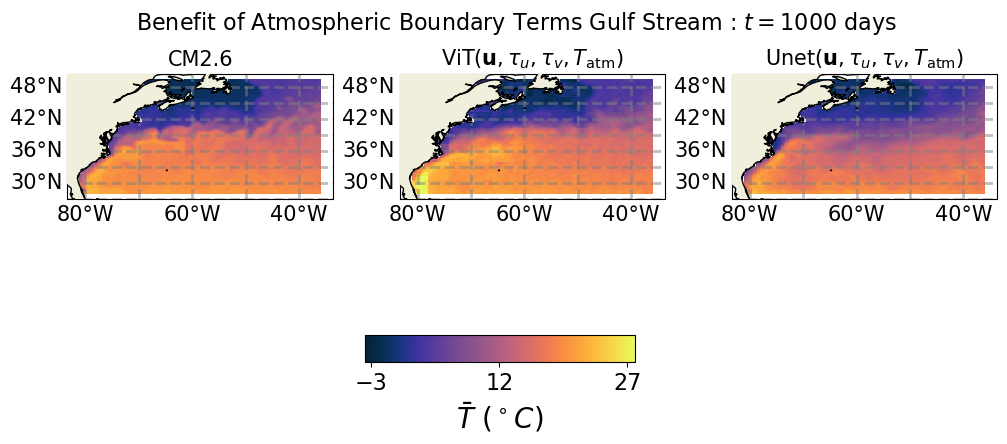

In [8]:
plt.rcParams.update({'font.size': 15})
var_list = {"1":r"$\bar{v}~~\mathrm{(m/s)}$","0":r"$\bar{u}~~\mathrm{(m/s)}$","2":r"$\bar{T} ~ (^\circ C)$"}

fig, axs = plt.subplots(2, 3, figsize=(12,5),
                        gridspec_kw={'width_ratios': [1,1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5},
                       subplot_kw={'projection': ccrs.PlateCarree()})

T_plot = 1000



vmin = mean_out[ind_plot]- std_out[ind_plot]
vmax = mean_out[ind_plot]+ std_out[ind_plot]

if region == "Tropics_Ext" and ind_plot == 2:
    vmin = mean_out[ind_plot]- (.5*std_out[ind_plot])
    vmax = mean_out[ind_plot]+ (std_out[ind_plot])
elif region == "Africa_Ext" and ind_plot == 2:
    vmin = mean_out[ind_plot]- (1.25*std_out[ind_plot])
    vmax = mean_out[ind_plot]+ (2*std_out[ind_plot])    
elif region == "Gulf_Stream_Ext" and ind_plot == 2:
    vmin = mean_out[ind_plot]- (1.75*std_out[ind_plot])
    vmax = mean_out[ind_plot]+ (1.75*std_out[ind_plot])   

if ind_plot in [0,1]:
    vmin -=std_out[ind_plot]
    vmax +=std_out[ind_plot]
    limit = np.round(np.max([abs(vmin),abs(vmax)]),1)
    vmin = -limit
    vmax = limit
    
x_plot = grids["x_C"][Nb:-Nb,Nb:-Nb]
y_plot = grids["y_C"][Nb:-Nb,Nb:-Nb]

if ind_plot == 2:
    cmap = cmocean.cm.thermal
else:
    cmap = cmocean.cm.diff


plt0 = axs[0,0].pcolormesh(x_plot, y_plot,
                      test_data[N_plot-1][1][ind_plot,Nb:-Nb,Nb:-Nb].cpu()*wet_nan[Nb:-Nb,Nb:-Nb]*std_out[ind_plot]+mean_out[ind_plot],
                  cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')



axs[0,0].add_feature(cart.feature.LAND, zorder=100, edgecolor='k')
gl = axs[0,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.yrotation = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
axs[0,0].set_title(r"CM2.6",size = 15)

pos = axs[1, 1].get_position()

# Set the new anchor point to be in the middle
new_pos = [pos.x0-.075, pos.y0+.15, pos.width*1.75, pos.height*1.5]  # Adjust 0.2 as needed

# Create a new axes with the adjusted position
cax = fig.add_axes(new_pos)


cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal",aspect=10)
cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels
if ind_plot == 2:
    cbar.set_ticks([np.ceil(vmin),np.round((vmin+vmax)/2), np.floor(vmax)])  
else:
    cbar.set_ticks([vmin,0, vmax])  
    
cbar.set_label(var_list[str(ind_plot)], fontsize=20)

fig.delaxes(axs[1,1])
fig.delaxes(cax)

plt1 = axs[0,1].pcolormesh(x_plot, y_plot,
                      model_pred_vit[T_plot-1,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb],
                  cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')

axs[0,1].add_feature(cart.feature.LAND, zorder=100, edgecolor='k')
gl = axs[0,1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.yrotation = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
axs[0,1].set_title(r"ViT($\mathbf{u},\tau_u,\tau_v,T_{\mathrm{atm}}$)",size = 15)


plt2 = axs[0,2].pcolormesh(x_plot, y_plot,
                      model_pred_unet[T_plot-1,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb],
                  cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')

axs[0,2].add_feature(cart.feature.LAND, zorder=100, edgecolor='k')
gl = axs[0,2].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.yrotation = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
axs[0,2].set_title(r"Unet($\mathbf{u},\tau_u,\tau_v,T_{\mathrm{atm}}$)",size = 15)

axs[1,0].set_axis_off()
axs[1,2].set_axis_off()

region_title = ""

for i in region:
    if region == "Quiescent_Ext":
        region_title = "South Pacific"
    elif region == "Africa_Ext":
        region_title = "African Cape"         
    elif i == "_":
        region_title += " "
    elif i == "E":
        break
    else:
        region_title+= i
region_title = str(region_title)

a = fig.suptitle(r"Benefit of Atmospheric Boundary Terms " +region_title+": $t = " +str(N_plot) +"$ days ", fontsize=16)


# plt.savefig("/scratch/as15415/Emulation/Figures/Snapshots_Vary_Boundary_"+region+"_ind_plot_"+str(ind_plot)+"_N_plot"+str(N_plot)+".png")

In [9]:
def update(i):
    plt0.set_array((test_data[i][1][ind_plot,Nb:-Nb,Nb:-Nb].cpu()*wet_nan[Nb:-Nb,Nb:-Nb]*std_out[ind_plot]+mean_out[ind_plot]).flatten())
    plt1.set_array((model_pred_vit[i,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb]).flatten())
    plt2.set_array((model_pred_unet[i,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb]).flatten())
    a.set_text(r"Benefit of Atmospheric Boundary Terms " +region_title+": $t = " +str(i+1) +"$ days ")

In [10]:
var_list = {"1":r"v","0":r"u","2":r"T"}

anim = FuncAnimation(fig, update, interval=100, frames=range(0,1000,2))
anim.save('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/videos/Video_Boundary_'+short_model_name+region+'_'+var_list[str(ind_plot)]+'.mp4')

# Error

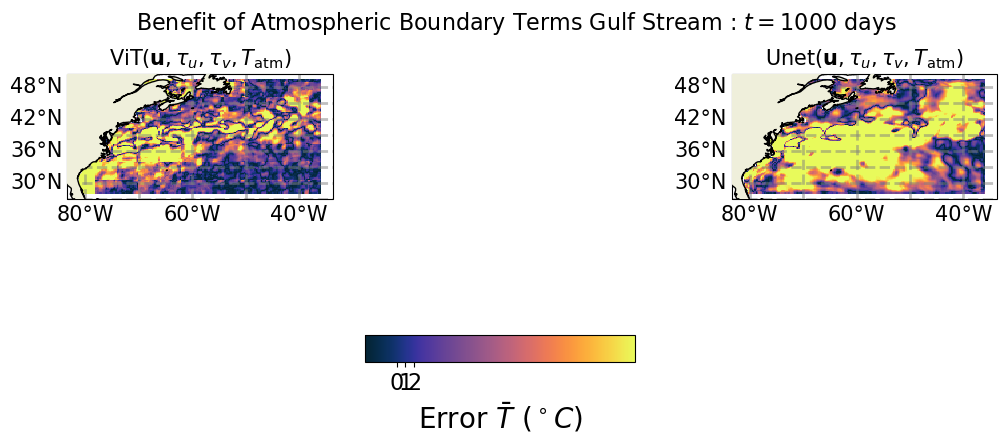

In [11]:
## Errors
plt.rcParams.update({'font.size': 15})
var_list = {"1":r"Error $\bar{v}~~\mathrm{(m/s)}$","0":r"Error $\bar{u}~~\mathrm{(m/s)}$","2":r"Error $\bar{T} ~ (^\circ C)$"}

fig, axs = plt.subplots(2, 3, figsize=(12,5),
                        gridspec_kw={'width_ratios': [1,1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5},
                       subplot_kw={'projection': ccrs.PlateCarree()})

T_plot = 1000


vmin = mean_out[ind_plot]- std_out[ind_plot]
vmax = mean_out[ind_plot]+ std_out[ind_plot]

if region == "Tropics_Ext" and ind_plot == 2:
    vmin = mean_out[ind_plot]- (.5*std_out[ind_plot])
    vmax = mean_out[ind_plot]+ (std_out[ind_plot])
elif region == "Africa_Ext" and ind_plot == 2:
    vmin = mean_out[ind_plot]- (1.25*std_out[ind_plot])
    vmax = mean_out[ind_plot]+ (2*std_out[ind_plot])    
elif region == "Gulf_Stream_Ext" and ind_plot == 2:
    vmin = mean_out[ind_plot]- (1.75*std_out[ind_plot])
    vmax = mean_out[ind_plot]+ (1.75*std_out[ind_plot])   

if ind_plot in [0,1]:
    vmin -=std_out[ind_plot]
    vmax +=std_out[ind_plot]
    limit = np.round(np.max([abs(vmin),abs(vmax)]),1)
    vmin = -limit
    vmax = limit
    
vmin = 0
vmax = 2
    
x_plot = grids["x_C"][Nb:-Nb,Nb:-Nb]
y_plot = grids["y_C"][Nb:-Nb,Nb:-Nb]

if ind_plot == 2:
    cmap = cmocean.cm.thermal
else:
    cmap = cmocean.cm.diff


true_plot_vals = test_data[N_plot-1][1][ind_plot,Nb:-Nb,Nb:-Nb].cpu()*wet_nan[Nb:-Nb,Nb:-Nb]*std_out[ind_plot]+mean_out[ind_plot]
# plt0 = axs[0,0].pcolormesh(x_plot, y_plot,
#                       true_plot_vals,
#                   cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')



# axs[0,0].add_feature(cart.feature.LAND, zorder=100, edgecolor='k')
# gl = axs[0,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                   linewidth=2, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.yrotation = False
# gl.xformatter = LONGITUDE_FORMATTER
# gl.yformatter = LATITUDE_FORMATTER
# axs[0,0].set_title(r"CM2.6",size = 15)

pos = axs[1, 1].get_position()

# Set the new anchor point to be in the middle
new_pos = [pos.x0-.075, pos.y0+.15, pos.width*1.75, pos.height*1.5]  # Adjust 0.2 as needed

# Create a new axes with the adjusted position
cax = fig.add_axes(new_pos)


cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal",aspect=10)
cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels
if ind_plot == 2:
    cbar.set_ticks([np.ceil(vmin),np.round((vmin+vmax)/2), np.floor(vmax)])  
else:
    cbar.set_ticks([vmin,0, vmax])  
    
cbar.set_label(var_list[str(ind_plot)], fontsize=20)

fig.delaxes(axs[1,1])
fig.delaxes(cax)

plt1 = axs[0,0].pcolormesh(x_plot, y_plot,
                      torch.abs(true_plot_vals - model_pred_vit[T_plot-1,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb]),
                  cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')

axs[0,0].add_feature(cart.feature.LAND, zorder=100, edgecolor='k')
gl = axs[0,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.yrotation = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
axs[0,0].set_title(r"ViT($\mathbf{u},\tau_u,\tau_v,T_{\mathrm{atm}}$)",size = 15)


plt2 = axs[0,2].pcolormesh(x_plot, y_plot,
                      torch.abs(true_plot_vals - model_pred_unet[T_plot-1,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb]),
                  cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')

axs[0,2].add_feature(cart.feature.LAND, zorder=100, edgecolor='k')
gl = axs[0,2].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.yrotation = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
axs[0,2].set_title(r"Unet($\mathbf{u},\tau_u,\tau_v,T_{\mathrm{atm}}$)",size = 15)

axs[1,0].set_axis_off()
axs[1,2].set_axis_off()
axs[0,1].set_axis_off()

region_title = ""

for i in region:
    if region == "Quiescent_Ext":
        region_title = "South Pacific"
    elif region == "Africa_Ext":
        region_title = "African Cape"         
    elif i == "_":
        region_title += " "
    elif i == "E":
        break
    else:
        region_title+= i
region_title = str(region_title)

a = fig.suptitle(r"Benefit of Atmospheric Boundary Terms " +region_title+": $t = " +str(N_plot) +"$ days ", fontsize=16)


# plt.savefig("/scratch/as15415/Emulation/Figures/Snapshots_Vary_Boundary_"+region+"_ind_plot_"+str(ind_plot)+"_N_plot"+str(N_plot)+".png")

In [12]:
def update(i):    
    true_vals = test_data[i][1][ind_plot,Nb:-Nb,Nb:-Nb].cpu()*wet_nan[Nb:-Nb,Nb:-Nb]*std_out[ind_plot]+mean_out[ind_plot]
    plt1.set_array((torch.abs(true_vals-model_pred_vit[i,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb])).flatten())
    plt2.set_array((torch.abs(true_vals-model_pred_unet[i,Nb:-Nb,Nb:-Nb,ind_plot]*wet_nan[Nb:-Nb,Nb:-Nb])).flatten())
    
    a.set_text(r"Benefit of Atmospheric Boundary Terms " +region_title+": $t = " +str(i+1) +"$ days ")

In [13]:
var_list = {"1":r"v","0":r"u","2":r"T"}

anim = FuncAnimation(fig, update, interval=100, frames=range(0,1000,2))
anim.save('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/videos/Video_Error_'+short_model_name+region+'_'+var_list[str(ind_plot)]+'.mp4')